In [1]:
%run -i ../../python_scripts/nb_setup.py

c:\Users\Emilien JEMELEN\Documents\SGR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [2]:
sgp_df_SR = pickle.load(open("sgp_set_tabular_SR", "rb"))
print(
    "N =",
    sgp_df_SR.shape[0],
    "Proportion of 1s: ",
    np.round(sgp_df_SR.y_true.sum() / sgp_df_SR.shape[0], 2),
)
sgp_df_SR.head(3)

N = 29884 Proportion of 1s:  0.12


,y_true,y_pred,kappa
0,0.0,0.0,0.655985
1,0.0,0.0,0.644825
2,0.0,0.0,0.613991


In [3]:
num_targets = 5000  # number of targets r* to consider when drawing metric/coverage of metric/theta curves
theta_min_SR, theta_max_SR = 0.5, 1  # Sn-independent grids
metric_targets = np.linspace(0, 1, num=num_targets)

Plot lines configuration (cosmetic) 

In [4]:
lines_list_1_SR, lines_list_2_SR, _, _, _ = lines()

## 1. __Unconditional risks__

### 1.1. __0/1 risk__

In [5]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=0
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

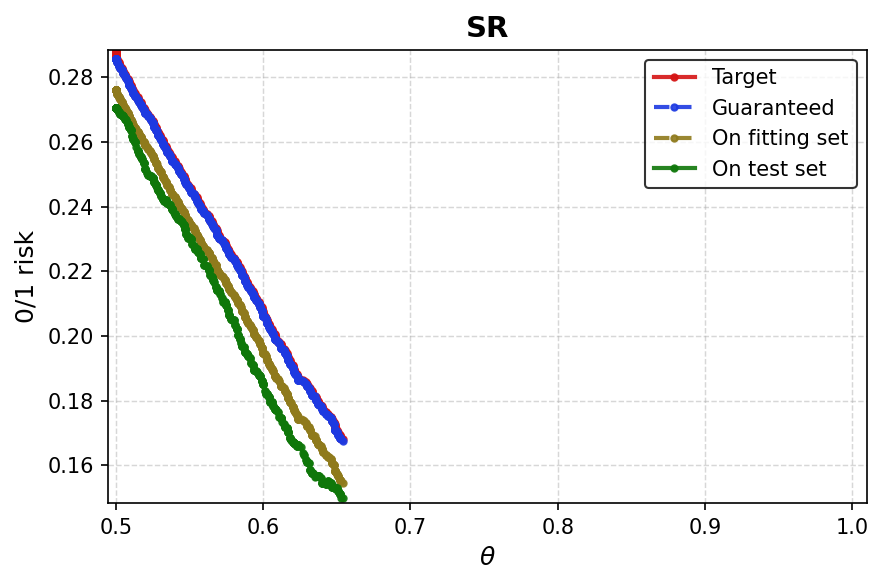

In [6]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

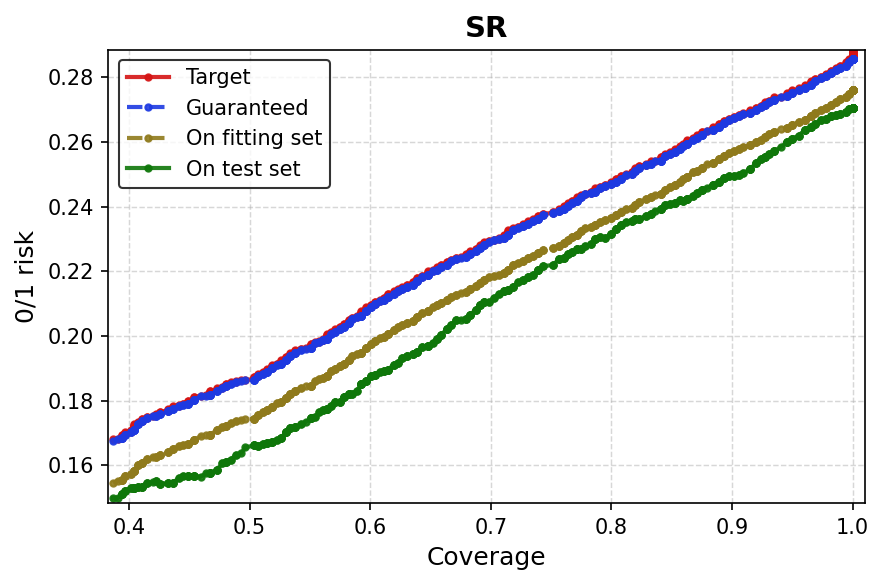

In [7]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

### 1.2. __FP risk__

In [8]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=1
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FP",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

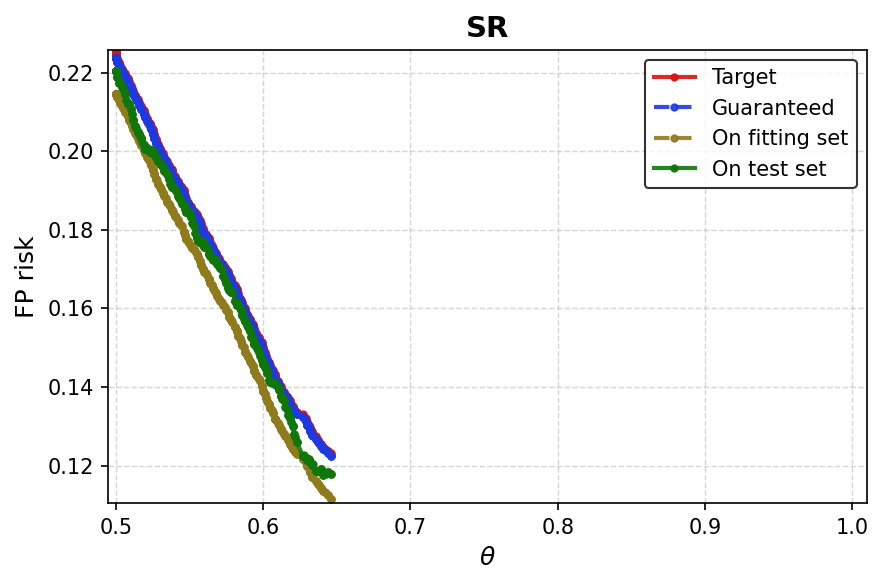

In [9]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

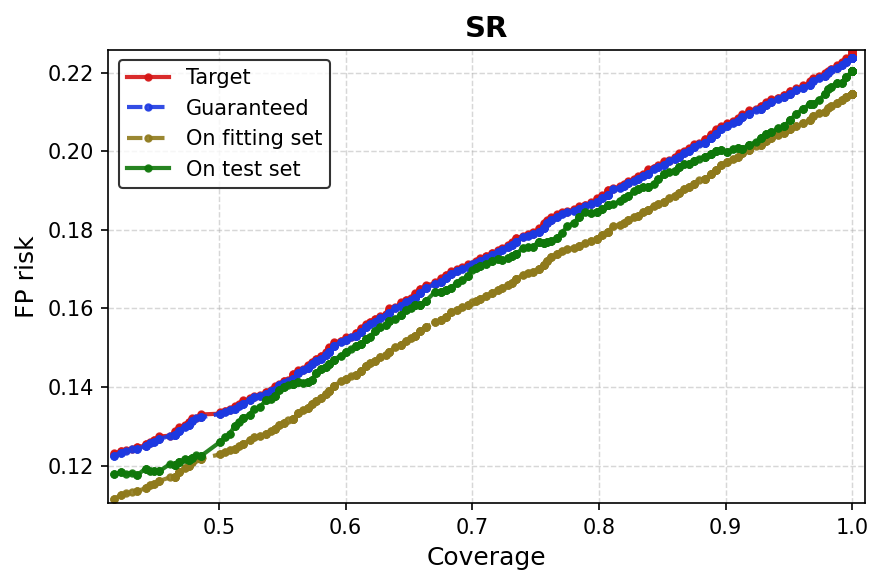

In [10]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

### 1.3. __FN risk__

In [11]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=2
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FN",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

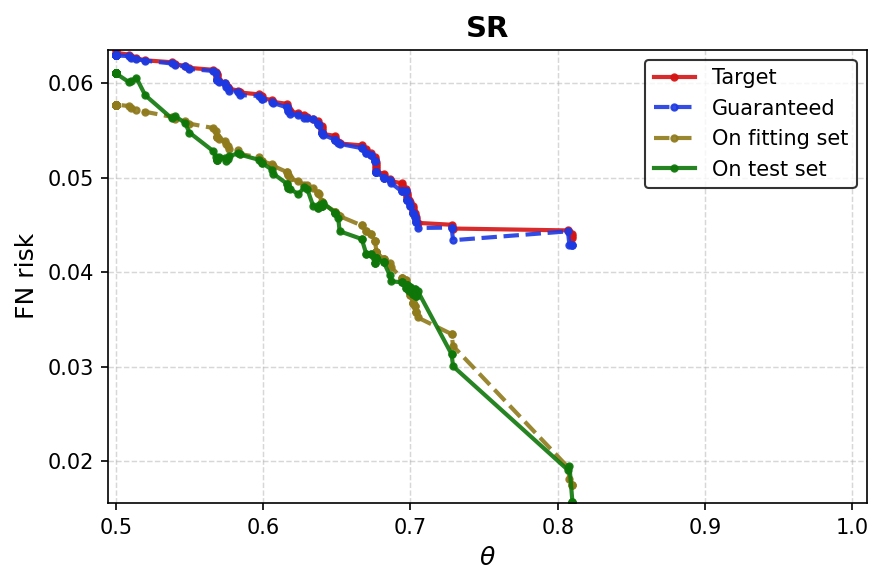

In [12]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

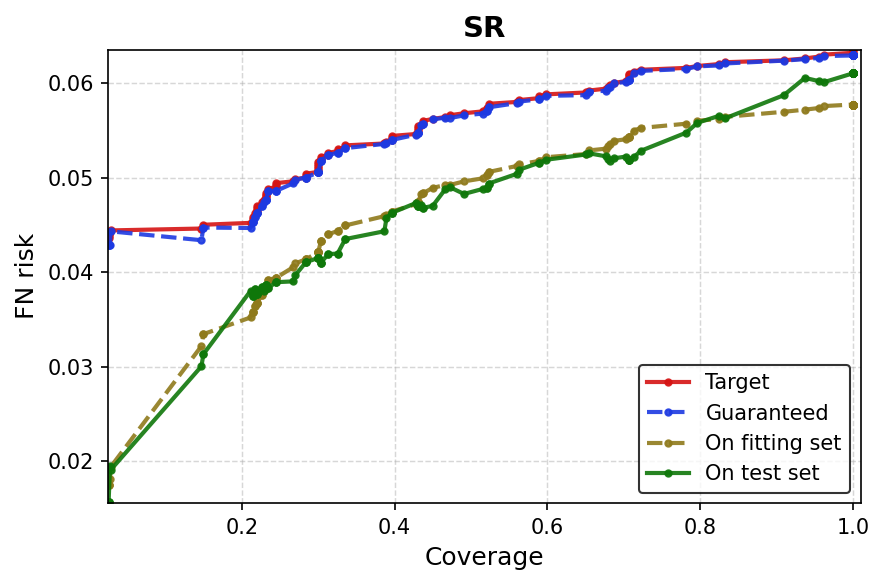

In [13]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

## __2. Conditional metrics__

### 2.1. __FPR__

In [14]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=3
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FPR",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

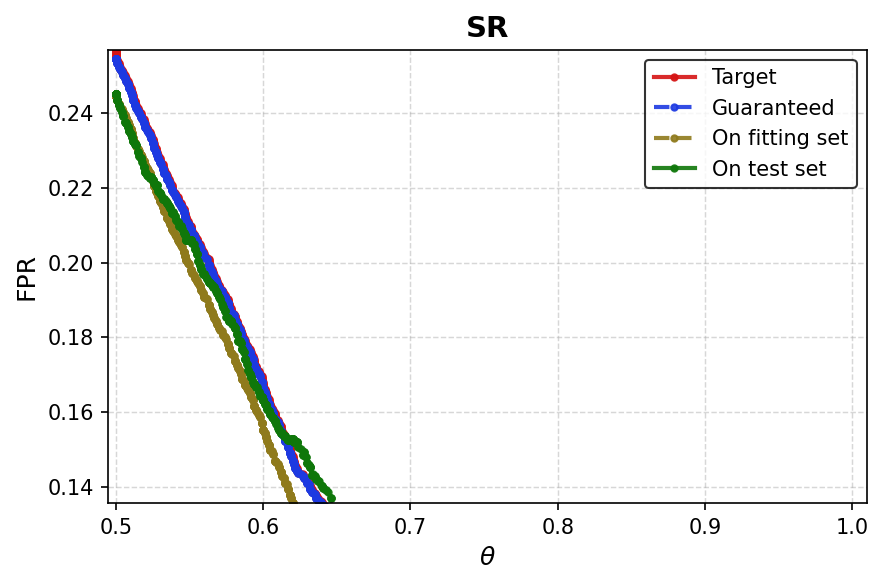

In [15]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

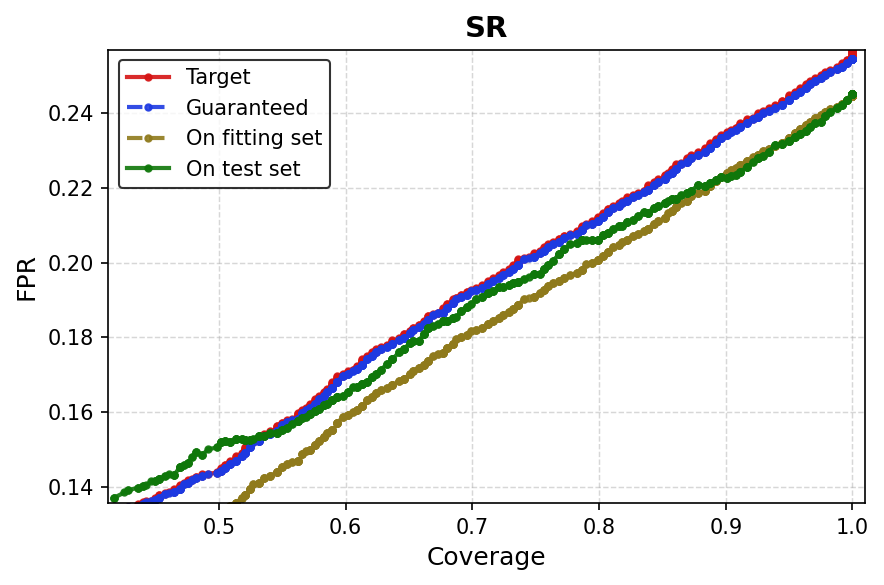

In [16]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

### 2.2. __FNR__

In [17]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=4
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FNR",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

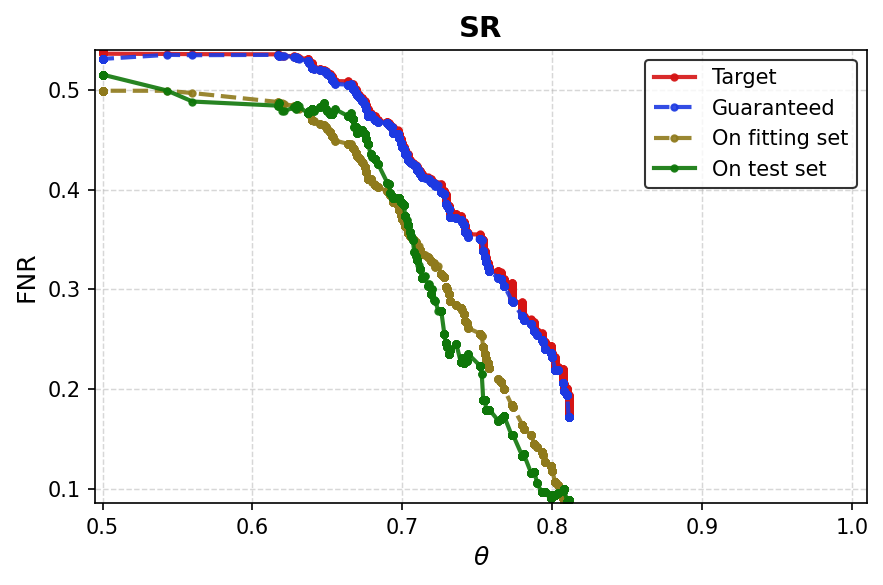

In [18]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

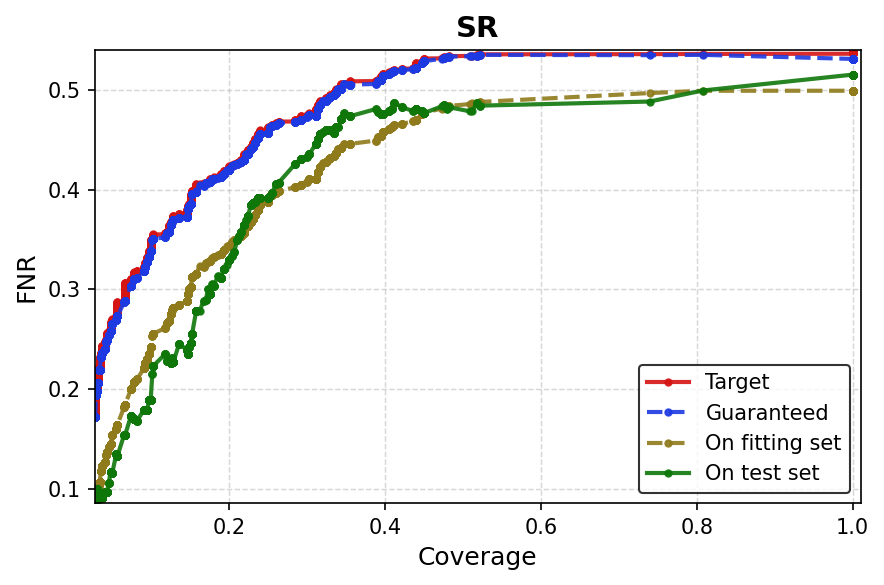

In [19]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

### 2.3. __PPV__

In [20]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=5
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="PPV",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

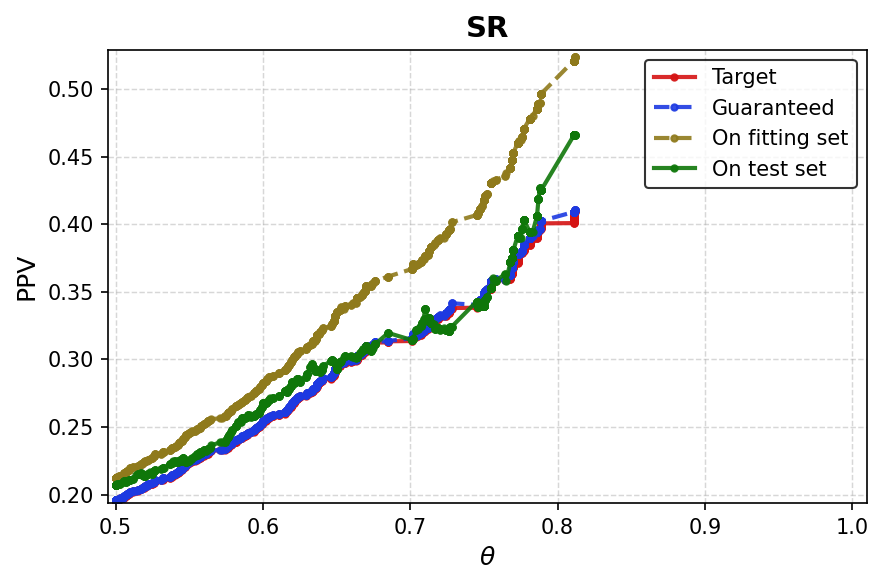

In [21]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

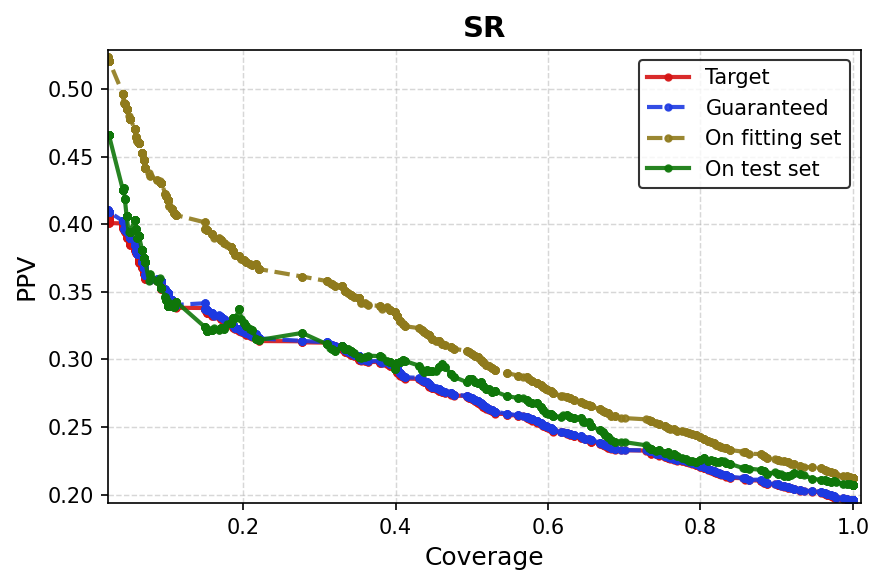

In [22]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

### 2.4. __SE__

In [23]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=6
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="SE",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

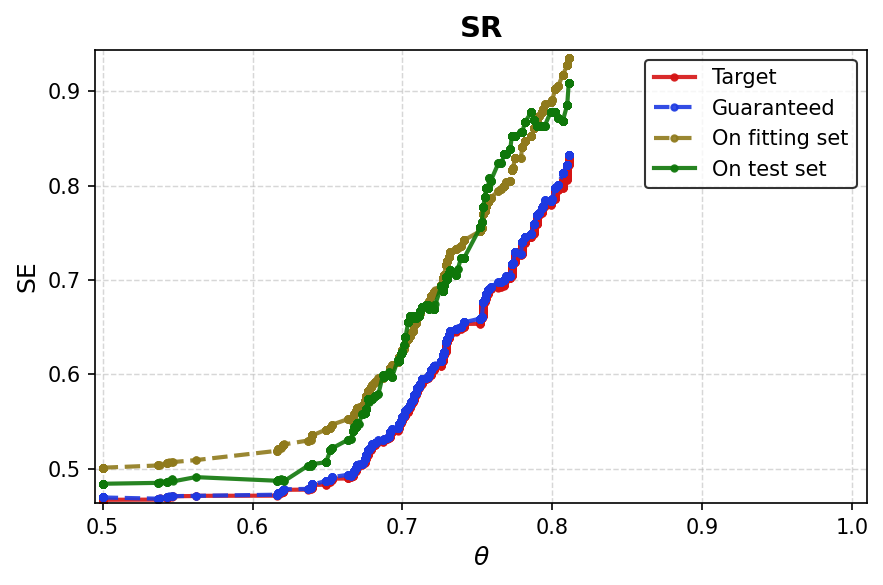

In [24]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

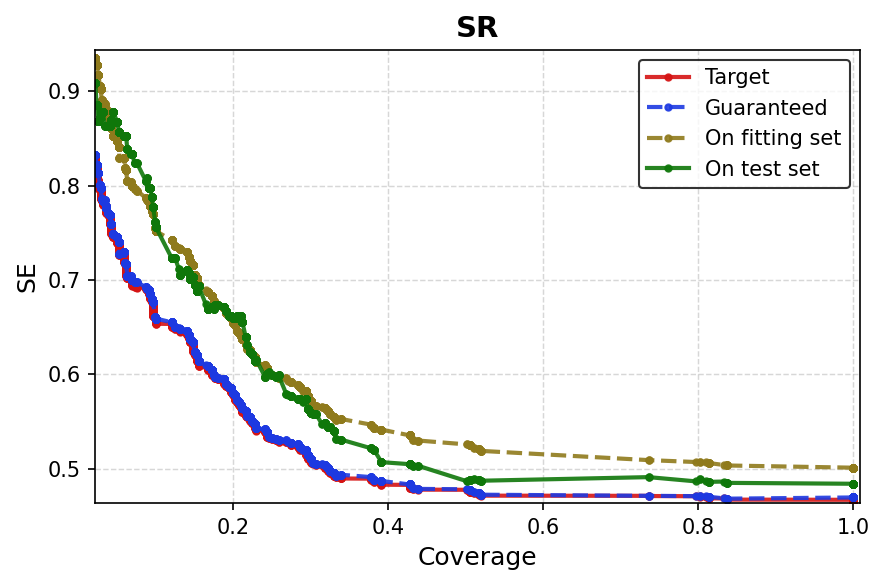

In [25]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

### 2.5. __SP__

In [26]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=7
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="SP",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

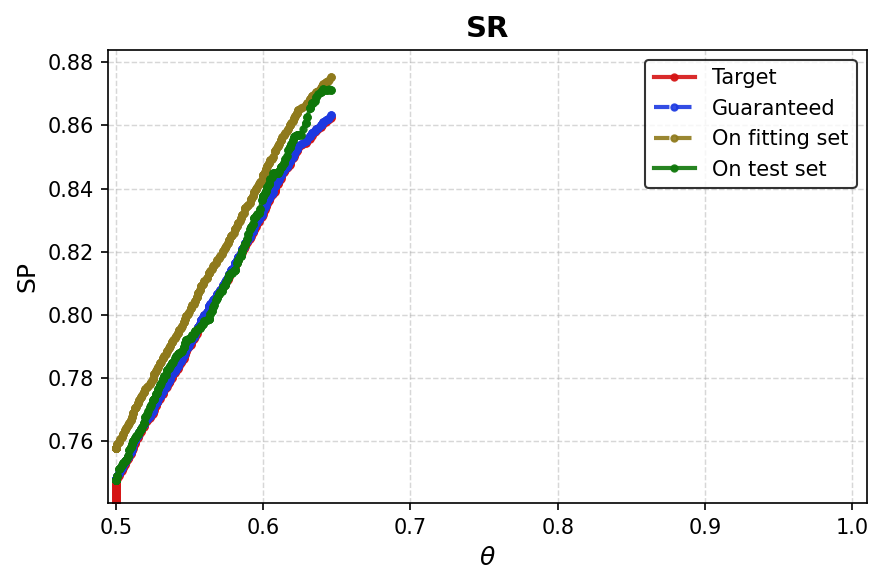

In [27]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

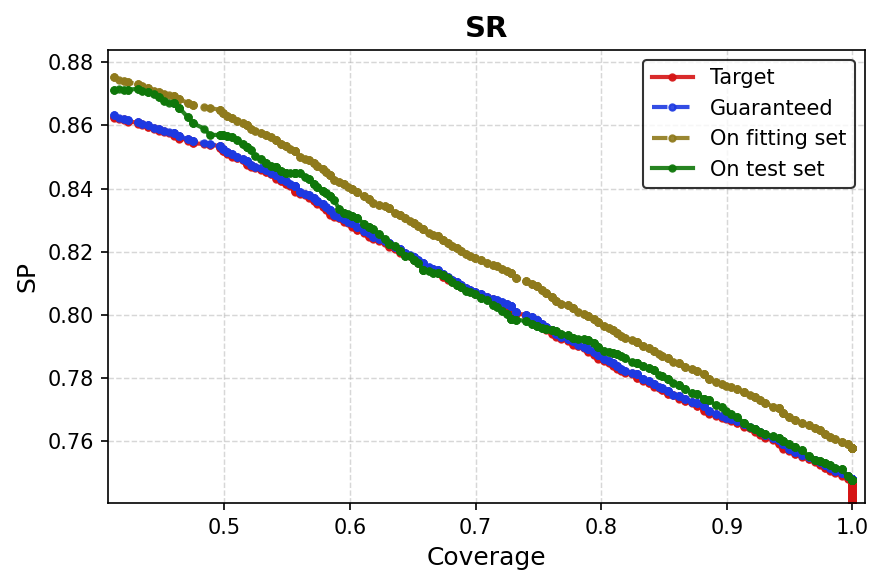

In [28]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)